In [1]:
# imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay



In [4]:
# data

#file_path = r"C:\Users\mrang\Downloads\master_0_dataset.csv"
file_path = "../data/master_rewrites_dataset.csv"
data = pd.read_csv(file_path)
data.head()

,id,text,label,generation_type,source,source_id
0,0,Title: Waqar Younis Resigns as Pakistan Coach...,ai,ai_rewrite,news,news_538
1,1,"Kolkata, India - West Indies' mercenary squad...",ai,ai_rewrite,news,news_416
2,2,"on. A female lies on her back, calling like cr...",human,human,essays_texts.csv,essays_1388_chunk3
3,3,LONDON: Joe Root was named Test Player of the ...,human,human,articles.csv,articles_1754
4,4,strong>ISLAMABAD: Guinness Book of World Recor...,human,human,articles.csv,articles_1994


## Data Cleaning

In [5]:
# normalize text/labels
data['text'] = data['text'].astype(str)
data['label'] = data['label'].str.lower().str.strip()

# numberic labels
label_map = {'human': 0, 'ai': 1}
data['label_num'] = data['label'].map(label_map)

# drop bad rows
data = data.dropna(subset=["text", "label_num"])
data = data[data["text"].str.strip() != ""]

In [6]:
# features + labels
X_text = data['text']
y = data['label_num']

In [7]:
# train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Initial Fit

In [8]:
# tf-idf features pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words='english',
        max_features=5000
    )),
    ("nb", MultinomialNB()) # naive bayes classifier
])

In [16]:
# fit on train + eval on test

pipeline.fit(X_train, y_train)

y_test_pred = pipeline.predict(X_test)
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["human", "ai"]))

Test Accuracy: 0.725

Test Classification Report:
              precision    recall  f1-score   support

       human       0.69      0.81      0.75       120
          ai       0.77      0.64      0.70       120

    accuracy                           0.72       240
   macro avg       0.73      0.73      0.72       240
weighted avg       0.73      0.72      0.72       240



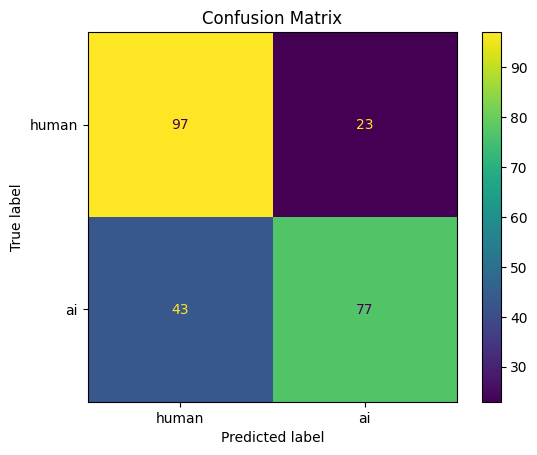

In [17]:
# confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["human", "ai"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

Test ROC AUC: 0.7714583333333332


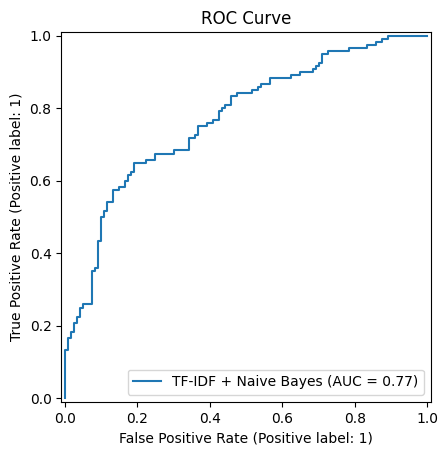

In [11]:
# roc auc

auc = roc_auc_score(y_test, y_test_proba)
print("Test ROC AUC:", auc)

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="TF-IDF + Naive Bayes"
)

plt.title("ROC Curve")
plt.show()

## 10-Fold CV

In [18]:
# stratified 10 fold cross validation 
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

accuracy_scores = cross_val_score(
    pipeline,
    X_text,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Accuracy scores for each fold:")
print(accuracy_scores)

print("\nMean accuracy:", accuracy_scores.mean())

Accuracy scores for each fold:
[0.68333333 0.675      0.71666667 0.63333333 0.65       0.775
 0.66666667 0.69166667 0.71666667 0.7       ]

Mean accuracy: 0.6908333333333334


In [19]:
# predictions + report
y_pred = cross_val_predict(
    pipeline,
    X_text,
    y,
    cv=cv
)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['human', 'ai']))


Classification Report:
              precision    recall  f1-score   support

       human       0.68      0.71      0.70       600
          ai       0.70      0.67      0.68       600

    accuracy                           0.69      1200
   macro avg       0.69      0.69      0.69      1200
weighted avg       0.69      0.69      0.69      1200




Confusion Matrix (Stratified):


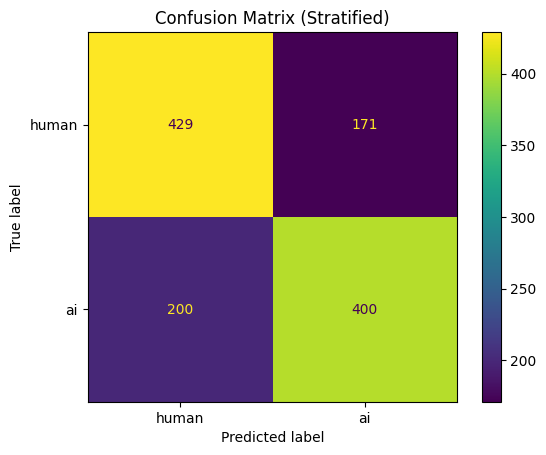

In [20]:
print("\nConfusion Matrix (Stratified):")
# confusion matrix

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["human", "ai"]
)

disp.plot()
plt.title("Confusion Matrix (Stratified)")
plt.show()

ROC AUC (Stratified): 0.7714583333333332


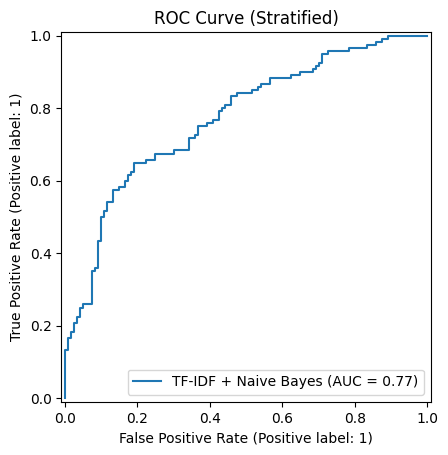

In [21]:
# roc auc

auc = roc_auc_score(y_test, y_test_proba)
print("ROC AUC (Stratified):", auc)

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="TF-IDF + Naive Bayes"
)

plt.title("ROC Curve (Stratified)")
plt.show()